In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [30]:
df = pd.read_csv("amazon.csv")

In [31]:
df.head()
df.shape
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   product_id           1465 non-null   str  
 1   product_name         1465 non-null   str  
 2   category             1465 non-null   str  
 3   discounted_price     1465 non-null   str  
 4   actual_price         1465 non-null   str  
 5   discount_percentage  1465 non-null   str  
 6   rating               1465 non-null   str  
 7   rating_count         1463 non-null   str  
 8   about_product        1465 non-null   str  
 9   user_id              1465 non-null   str  
 10  user_name            1465 non-null   str  
 11  review_id            1465 non-null   str  
 12  review_title         1465 non-null   str  
 13  review_content       1465 non-null   str  
 14  img_link             1465 non-null   str  
 15  product_link         1465 non-null   str  
dtypes: str(16)
memory usage: 4.7 MB


TO check missing values

In [32]:
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

Check duplicate rows

In [ ]:
df.duplicated().sum() #it returns the total count of duplicate rows as duplicated() just return T or F and then sum gives the total sum of T or F

np.int64(0)

Remove duplicate

In [34]:
df.drop_duplicates(inplace=True)

In [35]:
df['rating'].unique()

<ArrowStringArray>
['4.2', '4.0', '3.9', '4.1', '4.3', '4.4', '4.5', '3.7', '3.3', '3.6', '3.4',
 '3.8', '3.5', '4.6', '3.2', '5.0', '4.7', '3.0', '2.8',   '4', '3.1', '4.8',
 '2.3',   '|',   '2',   '3', '2.6', '2.9']
Length: 28, dtype: str

Clean Rating Column
Convert invalid values into numeric:

In [36]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

Handle Missing Rating Values

In [37]:
df['rating'] = df['rating'].fillna(df['rating'].mean())

In [38]:
df['discounted_price'] = df['discounted_price'].str.replace('₹', '')
df['discounted_price'] = df['discounted_price'].str.replace(',', '')
df['discounted_price'] = df['discounted_price'].astype(float)

In [39]:
df['actual_price'] = df['actual_price'].str.replace('₹', '')
df['actual_price'] = df['actual_price'].str.replace(',', '')
df['actual_price'] = df['actual_price'].astype(float)

In [40]:
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '')
df['discount_percentage'] = df['discount_percentage'].astype(float)

In [41]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating'] = df['rating'].fillna(df['rating'].mean())

In [42]:
df['rating_count'] = df['rating_count'].str.replace(',', '')
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce')
df['rating_count'] = df['rating_count'].fillna(df['rating_count'].median())

In [55]:
df['price_saved'] = df['actual_price'] - df['discounted_price']

In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   str    
 1   product_name         1465 non-null   str    
 2   category             1465 non-null   str    
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   float64
 6   rating               1465 non-null   float64
 7   rating_count         1465 non-null   float64
 8   about_product        1465 non-null   str    
 9   user_id              1465 non-null   str    
 10  user_name            1465 non-null   str    
 11  review_id            1465 non-null   str    
 12  review_title         1465 non-null   str    
 13  review_content       1465 non-null   str    
 14  img_link             1465 non-null   str    
 15  product_link         1465 non-null   str    
 16 

In [57]:
df['high_discount'] = df['discount_percentage'].apply(lambda x: 'Yes' if x > 50 else 'No')

In [58]:
df['normalized_price'] = (
    (df['discounted_price'] - df['discounted_price'].min()) /
    (df['discounted_price'].max() - df['discounted_price'].min())
)

In [59]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,high_discount,normalized_price,price_saved
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64.0,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,Yes,0.004618,700.0
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43.0,4.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...,No,0.002053,150.0
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90.0,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...,Yes,0.002053,1700.0
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53.0,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...,Yes,0.003720,370.0
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61.0,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...,Yes,0.001475,245.0


In [60]:
df['rating'].mean()

np.float64(4.096584699453551)

In [61]:
df[['product_name', 'rating']].sort_values(by='rating', ascending=False).head(10)

,product_name,rating
775,Amazon Basics Wireless Mouse | 2.4 GHz Connect...,5.0
174,Syncwire LTG to USB Cable for Fast Charging Co...,5.0
324,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",5.0
1299,"Instant Pot Air Fryer, Vortex 2QT, Touch Contr...",4.8
1145,Swiffer Instant Electric Water Heater Faucet T...,4.8
1201,"Oratech Coffee Frother electric, milk frother ...",4.8
1388,Campfire Spring Chef Prolix Instant Portable W...,4.7
1223,"FIGMENT Handheld Milk Frother Rechargeable, 3-...",4.7
1275,Multifunctional 2 in 1 Electric Egg Boiling St...,4.7
1226,Zuvexa USB Rechargeable Electric Foam Maker - ...,4.7


In [62]:
df[['product_name', 'discount_percentage']].sort_values(by='discount_percentage', ascending=False).head(10)

,product_name,discount_percentage
695,"rts [2 Pack] Mini USB C Type C Adapter Plug, T...",94.0
372,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91.0
380,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91.0
364,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91.0
368,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91.0
334,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91.0
557,LAPSTER 12pcs Spiral Cable Protectors for Char...,90.0
920,"Silicone Rubber Earbuds Tips, Eartips, Earpads...",90.0
644,Sounce Spiral Charger Cable Protector Data Cab...,90.0
407,Sounce Spiral Charger Cable Protector Data Cab...,90.0


In [63]:
df.groupby('category')['rating'].mean()

category
Car&Motorbike|CarAccessories|InteriorAccessories|AirPurifiers&Ionizers                                                    3.800000
Computers&Accessories|Accessories&Peripherals|Adapters|USBtoUSBAdapters                                                   4.150000
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCHeadsets                                           3.500000
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCMicrophones                                        3.600000
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCSpeakers                                           4.050000
                                                                                                                            ...   
OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|GelInkRollerballPens        4.250000
OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSu

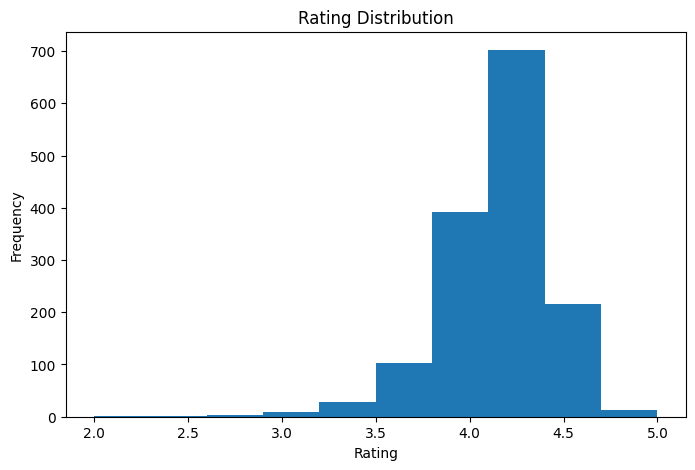

In [64]:
plt.figure(figsize=(8,5))
plt.hist(df['rating'])
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

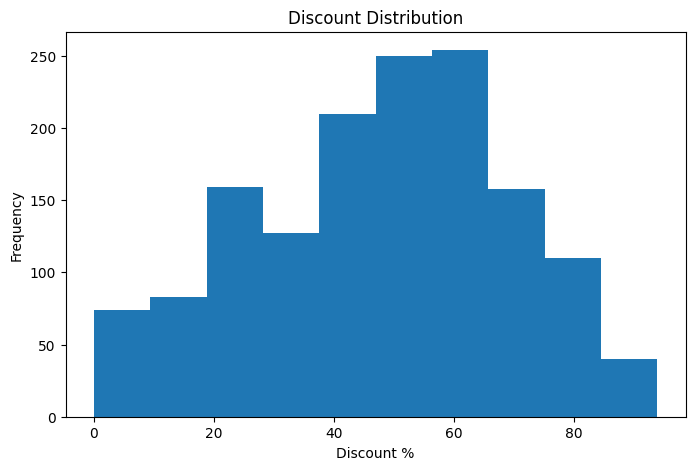

In [65]:
plt.figure(figsize=(8,5))
plt.hist(df['discount_percentage'])
plt.title("Discount Distribution")
plt.xlabel("Discount %")
plt.ylabel("Frequency")
plt.show()

In [66]:
df.to_csv("amazon_cleaned.csv", index=False)

In [ ]:
print("Final Dataset Shape:", df.shape)
print("Missing Values Remaining:")
print(df.isnull().sum())

Final Dataset Shape: (1465, 19)
Missing Values Remaining:
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
high_discount          0
normalized_price       0
price_saved            0
dtype: int64
